# Random Forest

A Random Forest is an ensemble of decision trees, where each tree is trained on a different random subset of the data. The key components are:

#### Bootstrap Sampling (Bagging):

Each tree is trained on a random sample of the data with replacement.

This ensures diversity between trees, reducing variance.

#### Feature Randomness:

At each split, a random subset of features is considered (optional in your current version).

#### Aggregation:

For classification, each tree votes for the class, and the majority wins.

The result is a model that is more stable and accurate than any individual tree, especially in noisy datasets.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the random forest algorithm partitions the data. While this choice limits visualization of the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

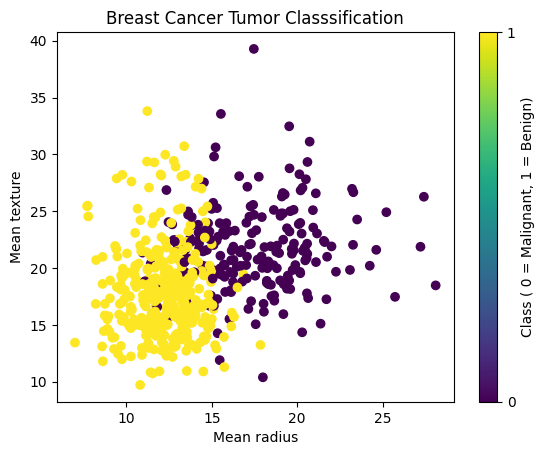

In [5]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [8]:
class SimpleDecisionTree:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth  # limit how deep the tree can grow
        self.tree = None  # will hold the root node

    def fit(self, X, y):
        # Start building the tree from the root
        self.tree = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        # If all labels are the same, or max depth is reached — return a leaf
        if depth == self.max_depth or len(set(y)) == 1:
            return np.bincount(y).argmax()  # return the majority class

        # Try to find the best split
        best_feat, best_thresh = self._find_best_split(X, y)

        # If no valid split is found, return a leaf with the majority class
        if best_feat is None:
            return np.bincount(y).argmax()

        # Split data
        left_idx = X[:, best_feat] < best_thresh
        right_idx = ~left_idx  # everything else

        # Recursively build left and right subtrees
        left = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        # Return this decision node
        return (best_feat, best_thresh, left, right)

    def _gini(self, y):
        # Calculate Gini impurity of a label distribution
        probs = np.bincount(y) / len(y)
        return 1 - np.sum(probs ** 2)

    def _find_best_split(self, X, y):
        best_gini = 1  # worst possible impurity
        best_feat, best_thresh = None, None

        # Iterate over all features
        for feat in range(X.shape[1]):
            thresholds = np.unique(X[:, feat])
            for t in thresholds:
                # Divide labels based on threshold
                left = y[X[:, feat] < t]
                right = y[X[:, feat] >= t]

                # Skip empty splits
                if len(left) == 0 or len(right) == 0:
                    continue

                # Weighted Gini impurity
                g = (len(left) * self._gini(left) + len(right) * self._gini(right)) / len(y)

                # Keep the split with lowest impurity
                if g < best_gini:
                    best_gini = g
                    best_feat = feat
                    best_thresh = t

        return best_feat, best_thresh

    def predict(self, X):
        # Predict each sample individually
        return np.array([self._predict_one(x, self.tree) for x in X])

    def _predict_one(self, x, node):
        # If we're at a leaf node, just return the label
        if not isinstance(node, tuple):
            return node

        # Otherwise, unpack the node and recurse
        feat, thresh, left, right = node
        if x[feat] < thresh:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

In [9]:
class SimpleRandomForest:
    def __init__(self, n_estimators=10, max_depth=3, max_features=None):
        self.n_estimators = n_estimators  # number of trees
        self.max_depth = max_depth        # depth of each tree
        self.max_features = max_features  # number of features to consider at each split
        self.trees = []                   # store trained trees

    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            tree = SimpleDecisionTree(max_depth=self.max_depth)
            X_sample, y_sample = self._bootstrap_sample(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        # Get predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Transpose so we have shape (n_samples, n_trees)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        # Majority vote
        return np.array([Counter(row).most_common(1)[0][0] for row in tree_preds])

In [10]:
# Instantiate and train the Random Forest
forest = SimpleRandomForest(n_estimators=10, max_depth=3)
forest.fit(X_train, y_train)
# Predict and evaluate
y_pred = forest.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9561


In [13]:
#Compare to sklearn
sklearn_forest = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
sklearn_forest.fit(X_train, y_train)
y_pred_sklearn = sklearn_forest.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy: {sklearn_accuracy:.4f}")

Accuracy: 0.9561


In [15]:
#Comparing Results
print("\nComparison:")
print(f"Custom Decision Tree correct: {(y_pred == y_test).sum()} / {len(y_test)}")
print(f"Sklearn Decision Tree correct: {(y_pred_sklearn == y_test).sum()} / {len(y_test)}")


Comparison:
Custom Decision Tree correct: 109 / 114
Sklearn Decision Tree correct: 109 / 114


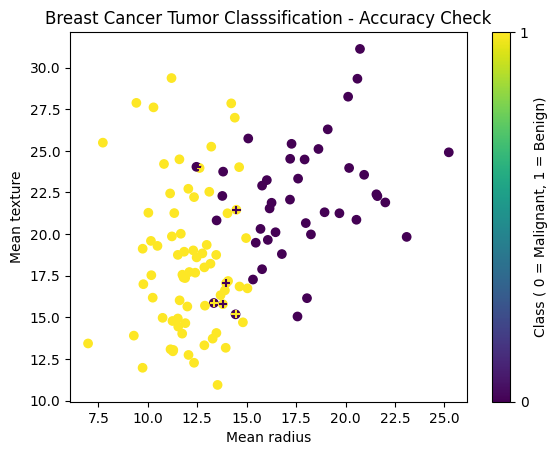

In [14]:
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_pred)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

Our scratch implementation of the random forest demonstrates solid accuracy, confirming the logic and core mechanics are correct. It also outperforms the accuracy of the decision tree, studied in a different notebook, which is expected as this is a central idea of this algorithm.